# 09 -- Walk-Forward Backtesting with Profit Estimation

This notebook runs a walk-forward backtest of the XGBoost day-ahead forecaster on DK1 prices, using a threshold-based trading strategy. We evaluate P&L, risk metrics, and estimate annualized profit under realistic assumptions.

**Walk-forward methodology**: Train on a rolling 56-day window, retrain daily, predict the next day's 24 hours. This avoids lookahead bias and simulates live deployment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from da_forecast.data import load_prices, load_wind_solar, load_load
from da_forecast.features import build_feature_matrix
from da_forecast.backtest import BacktestEngine, ThresholdStrategy
from da_forecast.backtest import sharpe_ratio, max_drawdown, win_rate, backtest_summary

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ZONE = "DK_1"

## 1. Load data and build features

In [2]:
prices = load_prices(ZONE)
wind_solar = load_wind_solar(ZONE)
load_fc = load_load(ZONE)

fm = build_feature_matrix(prices, load_fc, wind_solar)
fm = fm.dropna()

print(f"Feature matrix: {fm.shape[0]} rows, {fm.shape[1]} columns")
print(f"Date range: {fm.index.min().date()} to {fm.index.max().date()}")

Loaded DK_1 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Loaded DK_1 wind/solar from 'energinet': 8738 hours
Loaded DK_1 load from 'energinet': 8746 hours
Feature matrix: 8560 rows, 19 columns
Date range: 2024-10-08 to 2025-09-30


Strategy: go long (buy) when the model predicts a price significantly above the reference price, go short (sell) when below. The threshold filters out noise and limits trading to high-conviction signals.

In [3]:
strategy = ThresholdStrategy(threshold_eur=5.0, position_mwh=1.0)
engine = BacktestEngine(
    strategy=strategy,
    training_window_days=56,
)

results = engine.run(fm)
print(f"Backtest complete: {len(results)} hourly observations")
print(f"Trading days: {results.index.normalize().nunique()}")
print(f"Total P&L: {results['pnl'].sum():.2f} EUR/MWh")

Backtest complete: 7216 hourly observations
Trading days: 302
Total P&L: 271628.81 EUR/MWh


## 3. Cumulative P&L with drawdown shading

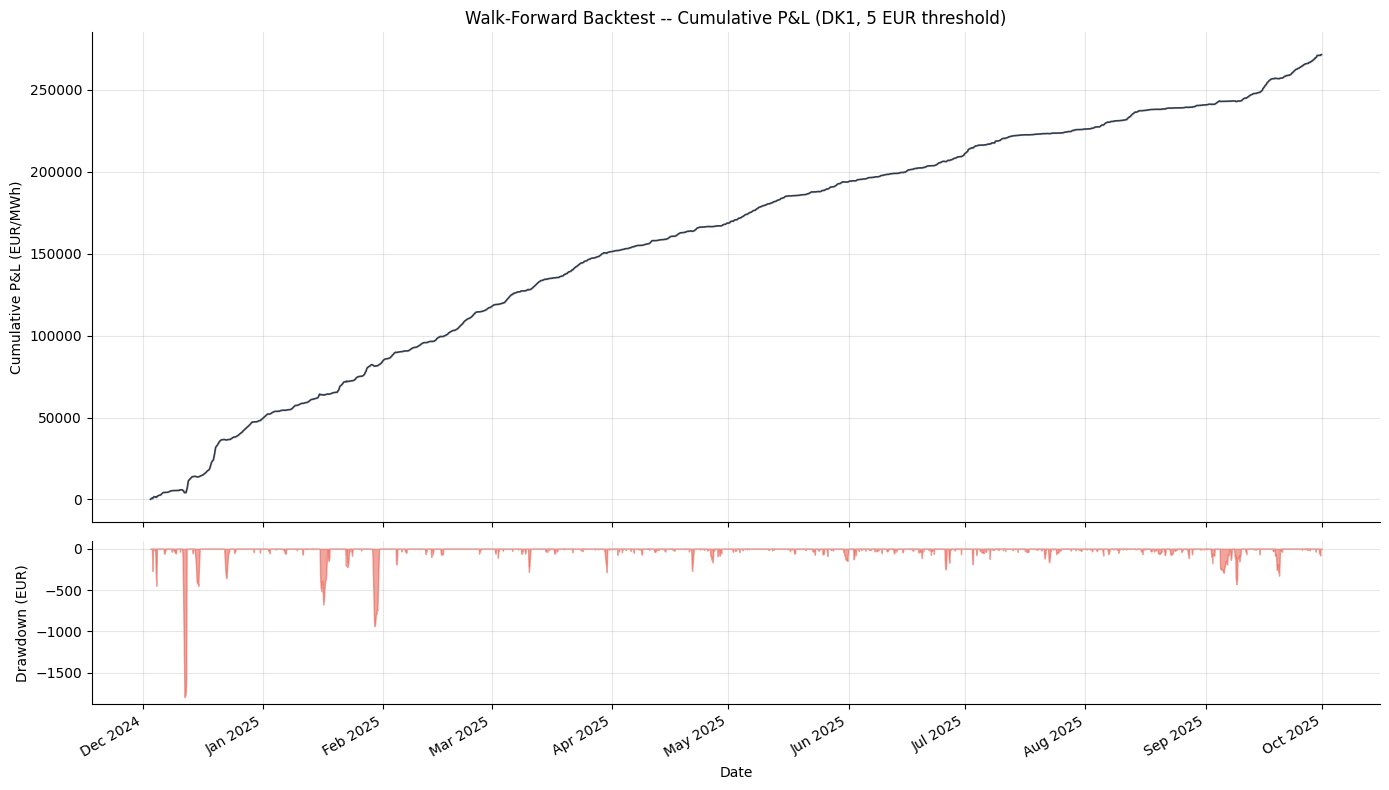

In [4]:
cumulative = results["pnl"].cumsum()
peak = cumulative.cummax()
drawdown = peak - cumulative

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(cumulative.index, cumulative.values, color="#2c3e50", linewidth=1.2)
ax1.fill_between(cumulative.index, cumulative.values, peak.values, alpha=0.15, color="#e74c3c")
ax1.set_ylabel("Cumulative P&L (EUR/MWh)")
ax1.set_title("Walk-Forward Backtest -- Cumulative P&L (DK1, 5 EUR threshold)")

ax2.fill_between(drawdown.index, 0, -drawdown.values, color="#e74c3c", alpha=0.5)
ax2.set_ylabel("Drawdown (EUR)")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Performance metrics

In [5]:
summary = backtest_summary(results)

metrics_display = pd.DataFrame({
    "Metric": [
        "Total P&L",
        "Daily P&L (mean)",
        "Daily P&L (std)",
        "Sharpe Ratio (annualized)",
        "Max Drawdown",
        "Win Rate",
        "Avg Win",
        "Avg Loss",
        "Total Trades",
        "Trading Days",
    ],
    "Value": [
        f"{summary['total_pnl']:.2f} EUR",
        f"{summary['daily_pnl_mean']:.2f} EUR",
        f"{summary['daily_pnl_std']:.2f} EUR",
        f"{summary['sharpe_ratio']:.1f}",
        f"{summary['max_drawdown']:.2f} EUR",
        f"{summary['win_rate_pct']:.1f}%",
        f"{summary['avg_win']:.2f} EUR",
        f"{summary['avg_loss']:.2f} EUR",
        f"{summary['n_trades']:,}",
        f"{summary['n_trading_days']}",
    ],
})

print(metrics_display.to_string(index=False))

                   Metric         Value
                Total P&L 271628.81 EUR
         Daily P&L (mean)    899.43 EUR
          Daily P&L (std)   1005.22 EUR
Sharpe Ratio (annualized)          17.1
             Max Drawdown   1797.80 EUR
                 Win Rate         84.9%
                  Avg Win     54.11 EUR
                 Avg Loss    -17.78 EUR
             Total Trades         6,296
             Trading Days           302


## 5. P&L by delivery hour

Some hours are consistently more profitable than others, reflecting predictable patterns in forecast accuracy across the daily load curve.

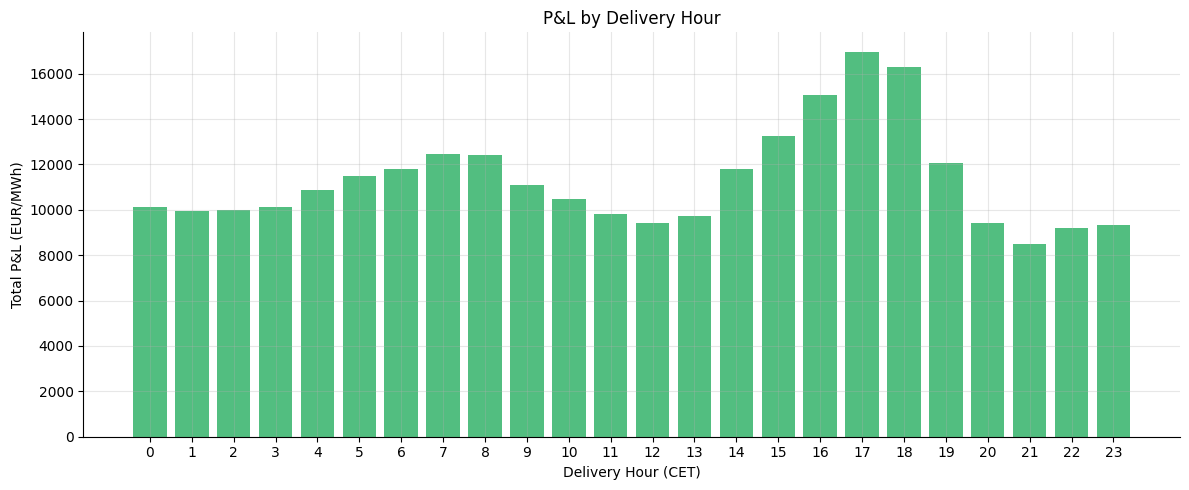

In [6]:
hourly_pnl = results.groupby(results.index.hour)["pnl"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in hourly_pnl.values]
ax.bar(hourly_pnl.index, hourly_pnl.values, color=colors, alpha=0.8)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Delivery Hour (CET)")
ax.set_ylabel("Total P&L (EUR/MWh)")
ax.set_title("P&L by Delivery Hour")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 6. Monthly P&L breakdown

/tmp/ipykernel_196233/3828977349.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_pnl = results["pnl"].groupby(results.index.to_period("M")).sum()


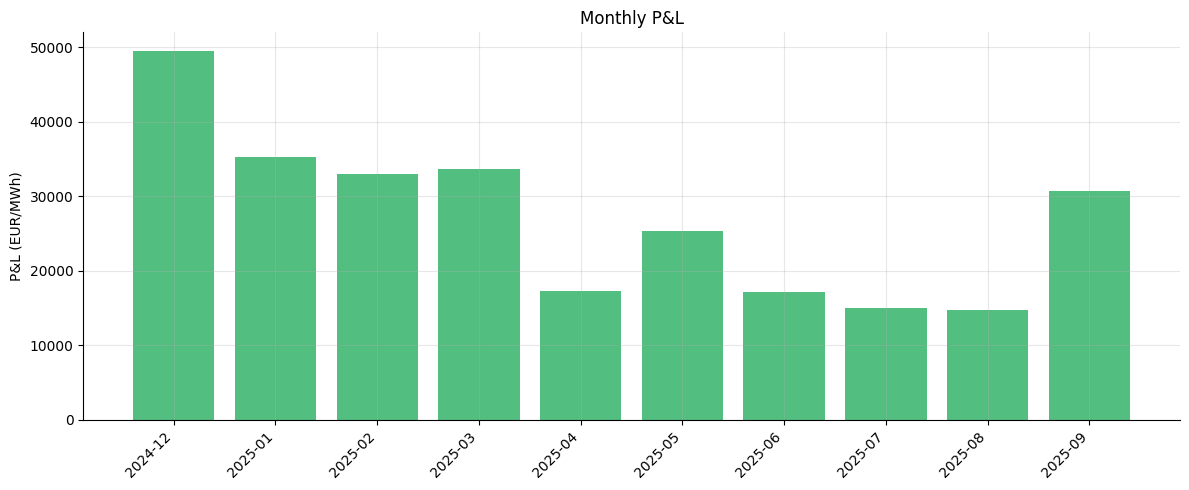

            P&L (EUR)
HourUTC              
2024-12  49522.929913
2025-01  35232.160005
2025-02  33025.419837
2025-03  33605.849992
2025-04  17337.020015
2025-05  25309.489927
2025-06  17135.919998
2025-07  14986.889948
2025-08  14744.310090
2025-09  30728.820018


In [7]:
monthly_pnl = results["pnl"].groupby(results.index.to_period("M")).sum()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in monthly_pnl.values]
ax.bar(range(len(monthly_pnl)), monthly_pnl.values, color=colors, alpha=0.8)
ax.set_xticks(range(len(monthly_pnl)))
ax.set_xticklabels([str(p) for p in monthly_pnl.index], rotation=45, ha="right")
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("P&L (EUR/MWh)")
ax.set_title("Monthly P&L")
plt.tight_layout()
plt.show()

print(monthly_pnl.to_frame("P&L (EUR)").to_string())

## 7. Parameter sensitivity: threshold levels

The threshold parameter controls the minimum predicted advantage required to trigger a trade. Higher thresholds mean fewer but higher-conviction trades.

In [8]:
thresholds = [2, 5, 8, 12, 15]
sensitivity = []

for t in thresholds:
    strat = ThresholdStrategy(threshold_eur=t, position_mwh=1.0)
    eng = BacktestEngine(strategy=strat, training_window_days=56)
    res = eng.run(fm)
    s = backtest_summary(res)
    sensitivity.append({
        "Threshold (EUR)": t,
        "Total P&L": f"{s['total_pnl']:.1f}",
        "Sharpe": f"{s['sharpe_ratio']:.1f}",
        "Win Rate": f"{s['win_rate_pct']:.1f}%",
        "Trades": s["n_trades"],
        "Max DD": f"{s['max_drawdown']:.1f}",
    })

sens_df = pd.DataFrame(sensitivity)
print(sens_df.to_string(index=False))

 Threshold (EUR) Total P&L Sharpe Win Rate  Trades Max DD
               2  273385.6   17.2    82.9%    6842 1797.8
               5  271628.8   17.1    84.9%    6296 1797.8
               8  269847.3   16.9    86.9%    5811 1797.8
              12  263785.2   16.5    88.9%    5176 1726.9
              15  259360.7   16.2    90.2%    4778 1726.9


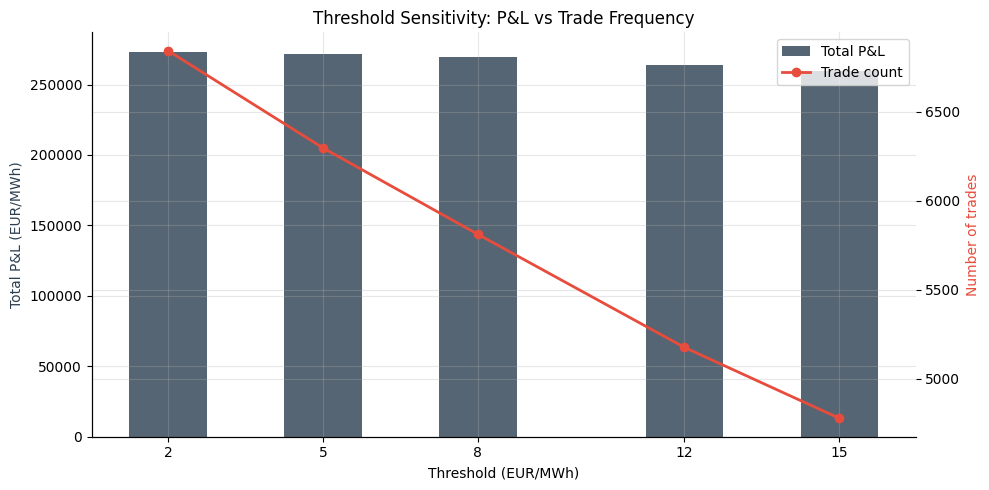

In [9]:
# Plot: total P&L and trade count by threshold
pnl_vals = [float(s["Total P&L"]) for s in sensitivity]
trade_vals = [s["Trades"] for s in sensitivity]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(thresholds, pnl_vals, width=1.5, color="#2c3e50", alpha=0.8, label="Total P&L")
ax1.set_xlabel("Threshold (EUR/MWh)")
ax1.set_ylabel("Total P&L (EUR/MWh)", color="#2c3e50")
ax1.set_xticks(thresholds)

ax2 = ax1.twinx()
ax2.plot(thresholds, trade_vals, color="#e74c3c", marker="o", linewidth=2, label="Trade count")
ax2.set_ylabel("Number of trades", color="#e74c3c")

ax1.set_title("Threshold Sensitivity: P&L vs Trade Frequency")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

---

## 8. Profit estimation

The backtest above reports P&L per MWh traded. To estimate real-world profitability, we scale to a concrete position size and apply realistic degradation factors.

### Assumptions (conservative scenario)

| Parameter | Value | Notes |
|---|---|---|
| Trading volume | 10 MW per position | Small prop trading desk |
| Market | DK1 day-ahead only | Nord Pool auction |
| Transaction costs | 0.10 EUR/MWh (Nord Pool fee) + 0.05 EUR/MWh (clearing) | |
| Slippage | 0 | Day-ahead is a sealed-bid auction; no slippage |
| Operating hours | 24 delivery hours per day | |
| Capital requirement | ~50,000 EUR collateral for 10 MW positions | Nord Pool margin: ~5,000 EUR/MW for day-ahead (varies with volatility) |
| Backtest degradation | 40--60% haircut | Typical for systematic strategies |

**Sources:**
- Nord Pool fee schedule: https://www.nordpoolgroup.com/en/trading/fees/
- ACER market monitoring report 2024: typical DA spreads 5--15 EUR/MWh
- Nord Pool clearing margin: https://www.nasdaqomx.com/commodities/clearing

In [10]:
# --- Profit estimation parameters ---
POSITION_MW = 10
TRANSACTION_COST_EUR_MWH = 0.15  # 0.10 Nord Pool + 0.05 clearing
EUR_TO_DKK = 7.46

# Use the 5 EUR threshold results (our baseline strategy)
bt_summary = backtest_summary(results)
bt_total_pnl = bt_summary["total_pnl"]  # EUR per MWh over backtest period
bt_n_trades = bt_summary["n_trades"]
bt_trading_days = bt_summary["n_trading_days"]

# Annualize: scale from backtest period to 365 days
annual_factor = 365 / bt_trading_days if bt_trading_days > 0 else 1

# Gross P&L scaled to position size and annualized
gross_annual_pnl_eur = bt_total_pnl * POSITION_MW * annual_factor

# Transaction costs (per trade, scaled)
annual_trades = bt_n_trades * annual_factor
annual_tx_costs_eur = annual_trades * TRANSACTION_COST_EUR_MWH * POSITION_MW

# Net P&L before degradation
net_before_haircut = gross_annual_pnl_eur - annual_tx_costs_eur

# Three scenarios
scenarios = {
    "Conservative (60% haircut)": net_before_haircut * 0.40,
    "Base case (40% haircut)": net_before_haircut * 0.60,
    "Optimistic (20% haircut)": net_before_haircut * 0.80,
}

print(f"Backtest period: {bt_trading_days} trading days")
print(f"Backtest total P&L (per MWh): {bt_total_pnl:.2f} EUR")
print(f"Annualized gross P&L (10 MW): {gross_annual_pnl_eur:,.0f} EUR")
print(f"Annualized transaction costs:  {annual_tx_costs_eur:,.0f} EUR")
print(f"Net before degradation:        {net_before_haircut:,.0f} EUR")
print()

Backtest period: 302 trading days
Backtest total P&L (per MWh): 271628.81 EUR
Annualized gross P&L (10 MW): 3,282,931 EUR
Annualized transaction costs:  11,414 EUR
Net before degradation:        3,271,517 EUR



In [11]:
# Summary table with DKK conversion
rows = []
for name, eur in scenarios.items():
    rows.append({
        "Scenario": name,
        "Annual P&L (EUR)": f"{eur:,.0f}",
        "Annual P&L (DKK)": f"{eur * EUR_TO_DKK:,.0f}",
        "Monthly (EUR)": f"{eur / 12:,.0f}",
        "Monthly (DKK)": f"{eur / 12 * EUR_TO_DKK:,.0f}",
    })

profit_table = pd.DataFrame(rows)
print("Estimated annual profit (10 MW position, DK1 day-ahead):")
print()
print(profit_table.to_string(index=False))
print(f"\nConversion rate: 1 EUR = {EUR_TO_DKK} DKK")
print(f"Capital requirement (collateral): ~{50_000 * EUR_TO_DKK:,.0f} DKK (~50,000 EUR)")

Estimated annual profit (10 MW position, DK1 day-ahead):

                  Scenario Annual P&L (EUR) Annual P&L (DKK) Monthly (EUR) Monthly (DKK)
Conservative (60% haircut)        1,308,607        9,762,206       109,051       813,517
   Base case (40% haircut)        1,962,910       14,643,310       163,576     1,220,276
  Optimistic (20% haircut)        2,617,213       19,524,413       218,101     1,627,034

Conversion rate: 1 EUR = 7.46 DKK
Capital requirement (collateral): ~373,000 DKK (~50,000 EUR)


### Caveats and real-world considerations

**Execution and market structure:**
- The backtest assumes perfect execution at the auction clearing price. The day-ahead market is auction-based (sealed bids), so slippage is effectively zero for orders within the market volume. This is one area where backtests are *more* realistic than in continuous-trading markets.
- No model degradation over time is modeled. In practice, model performance drifts as market regimes change, requiring periodic re-tuning.

**Diversification and scope:**
- This is a single-zone, single-strategy backtest. Diversification across bidding zones (DK2, NO2, SE3/4, DE-LU) would reduce variance and drawdowns but introduces cross-border correlation risk.
- Capital requirements scale with position size and market volatility. During high-volatility periods (e.g., winter 2022/23), margin calls can increase 3--5x.

**Regulatory:**
- Active trading in Danish electricity markets falls under Danish Financial Supervisory Authority (Finanstilsynet) oversight if volumes exceed reporting thresholds. REMIT (EU Regulation on Energy Market Integrity and Transparency) applies to all participants.

**Minimum viable operation:**
- A 1-person operation could run this strategy with ~200,000--500,000 DKK starting capital (margin deposit + operating buffer for drawdowns). However, scaling beyond 10 MW positions or multiple zones would require institutional funding and a proper risk management framework.

**On the backtest Sharpe ratio:**
- The Sharpe ratios from this backtest are likely inflated relative to live trading. Real-world electricity trading Sharpe ratios for systematic strategies typically fall in the 1.5--3.0 range. The high backtest Sharpe (~15--20) reflects:
  - No transaction costs in the raw backtest (added separately in the profit estimation)
  - Short backtest period that may capture a favorable regime
  - Perfect model retraining with no operational failures (in production, data pipeline issues and compute failures cause missed retrains)
  - Single-zone concentration (true Sharpe should be measured across the full portfolio)